In [1]:
# ==============================================================================
# 🎯 8th Semester CSE Portfolio Project: Custom 6M Conditional GAN (cGAN)
# 🚀 Hardware Automation Architecture: Automated TPU / GPU / CPU Selector
# 📊 Dataset: Oxford-IIIT Pet Dataset (Kaggle Native Channels)
# ==============================================================================

import os
import re
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------------------------
# 🖥️ 1. AUTOMATED HARDWARE ACCELERATOR SELECTOR (TPU vs GPU vs CPU)
# ------------------------------------------------------------------------------
print("⚙️ Detecting active hardware accelerator configuration...")

# Check for Kaggle TPU Environment first (PyTorch XLA Bridge)
try:
    import torch_xla.core.xla_model as xm
    # Ping the active context device safely
    _ = xm.xla_device()
    USE_TPU = True
    device = xm.xla_device()
    print("🖥️ System Alert: Kaggle TPU detected! Initializing distributed graph tensors.")
except (ImportError, RuntimeError):
    USE_TPU = False
    # Fallback to local CUDA GPU framework or host CPU core
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ System Alert: TPU not available. Native target initialized: {device.type.upper()}")

# ------------------------------------------------------------------------------
# 📦 2. KAGGLE DATASET PATH CONFIGURATION & MULTI-MODAL LOADER
# ------------------------------------------------------------------------------
IMAGE_DIR = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images"
if os.path.exists(os.path.join(IMAGE_DIR, "images")):
    IMAGE_DIR = os.path.join(IMAGE_DIR, "images")

class OxfordPetGANDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        all_files = os.listdir(img_dir)
        self.valid_images = []
        self.prompts = []
        self.unique_classes = set()
        
        for file in all_files:
            if file.endswith('.jpg') and not file.startswith('.'):
                breed_raw = re.sub(r'_\d+$', '', file.split('.')[0])
                breed_name = breed_raw.replace('_', ' ').title()
                
                # Strict Oxford Naming Convention mapping
                if file.isupper():
                    prompt = f"a photo of a {breed_name} cat"
                else:
                    prompt = f"a photo of a {breed_name} dog"
                
                self.valid_images.append(file)
                self.prompts.append(prompt)
                self.unique_classes.add(prompt)
                
        self.unique_classes = sorted(list(self.unique_classes))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.unique_classes)}
        print(f"🔍 Dataset Configured: Found {len(self.valid_images)} images within {len(self.unique_classes)} distinct prompts.")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.valid_images[idx])
        image = Image.open(img_name).convert("RGB")
        if self.transform:
            image = self.transform(image)
        prompt = self.prompts[idx]
        class_idx = self.class_to_idx[prompt]
        return image, torch.tensor(class_idx, dtype=torch.long)

# Balanced resizing to 64x64 resolution targeting clear feature maps
transform_pipeline = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Bound pixels between [-1, 1]
])

dataset = OxfordPetGANDataset(img_dir=IMAGE_DIR, transform=transform_pipeline)
NUM_CLASSES = len(dataset.unique_classes)
# Batch 64 provides high throughput on both T4 GPUs and Tensor Cores
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

# ------------------------------------------------------------------------------
# 🧱 3. STABLE CONDITIONAL GAN ARCHITECTURE DESIGN (~6M TOTAL PARAMS)
# ------------------------------------------------------------------------------

# Generator Network Structure: Projects Noise and Text Tokens to clean 64x64 Image
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, embed_dim=32, num_classes=37):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        # Base input projection layer
        self.init_layer = nn.Linear(latent_dim + embed_dim, 512 * 4 * 4)
        
        # Deep convolutional up-sampling pipeline
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Upsample(scale_factor=2), # 4x4 -> 8x8
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Upsample(scale_factor=2), # 8x8 -> 16x16
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Upsample(scale_factor=2), # 16x16 -> 32x32
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Upsample(scale_factor=2), # 32x32 -> 64x64
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh() # Projects pixel data precisely to matching bounds [-1, 1]
        )

    def forward(self, noise, labels):
        # Merge noise vector and text embeddings channel-wise
        cls_input = self.label_emb(labels)
        gen_input = torch.cat((noise, cls_input), dim=-1)
        out = self.init_layer(gen_input)
        out = out.view(out.shape[0], 512, 4, 4)
        return self.conv_blocks(out)

# Discriminator Network Structure: Classifies Real vs Fake conditioned on Text Tokens
class ConditionalDiscriminator(nn.Module):
    def __init__(self, embed_dim=32, num_classes=37):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        # Re-projecting labels into spatial image dimensions
        self.label_proj = nn.Linear(embed_dim, 3 * 64 * 64)
        
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1), # 64x64 -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 32x32 -> 16x16
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 16x16 -> 8x8
            nn.BatchNorm2d(256, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 8x8 -> 4x4
            nn.BatchNorm2d(512, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1) # Output single realness logit score
        )

    def forward(self, img, labels):
        # Re-shape text context matching image format and concatenate channel-wise
        lbl_flat = self.label_proj(self.label_emb(labels))
        lbl_spatial = lbl_flat.view(img.shape[0], 3, 64, 64)
        d_input = torch.cat((img, lbl_spatial), dim=1)
        return self.conv_blocks(d_input)

# 🚀 Parameter Weight Verification Block
LATENT_DIM = 100
generator = ConditionalGenerator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
discriminator = ConditionalDiscriminator(num_classes=NUM_CLASSES).to(device)

g_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"📊 Verified Parameter Count -> Generator: {g_params/1e6:.2f}M | Discriminator: {d_params/1e6:.2f}M | Combined Stable Scale: {(g_params+d_params)/1e6:.2f}M")

# ------------------------------------------------------------------------------
# ⚡ 4. OPTIMIZERS & STABLE ADVERSARIAL TRAINING LOOP
# ------------------------------------------------------------------------------
# Standard stable GAN configurations: Binary Cross Entropy and explicit learning bounds
adversarial_loss = nn.BCEWithLogitsLoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

# 30-50 epochs provide high visual sharpness on cGANs
EPOCHS = 35 
print(f"\n🎬 Initiating GAN Adversarial Loop! Running {EPOCHS} Stable Milestones...")

for epoch in range(EPOCHS):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (real_imgs, labels) in progress_bar:
        batch_size = real_imgs.shape[0]
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        
        # Ground truth tensor variables
        valid_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)
        
        # ---------------------------------
        # 🚂 Step A: Train Discriminator
        # ---------------------------------
        optimizer_D.zero_grad()
        
        # Loss on real dataset distribution
        real_logits = discriminator(real_imgs, labels)
        loss_real = adversarial_loss(real_logits, valid_targets)
        
        # Loss on generated fake distribution
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(z, labels)
        fake_logits = discriminator(fake_imgs.detach(), labels)
        loss_fake = adversarial_loss(fake_logits, fake_targets)
        
        # Aggregate loss backprop step
        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        
        if USE_TPU:
            xm.optimizer_step(optimizer_D, barrier=True)
        else:
            optimizer_D.step()
            
        epoch_d_loss += loss_D.item()
        
        # ---------------------------------
        # 🚂 Step B: Train Generator
        # ---------------------------------
        optimizer_G.zero_grad()
        
        # Measure generator's ability to fool the discriminator
        gen_logits = discriminator(fake_imgs, labels)
        loss_G = adversarial_loss(gen_logits, valid_targets)
        loss_G.backward()
        
        if USE_TPU:
            xm.optimizer_step(optimizer_G, barrier=True)
        else:
            optimizer_G.step()
            
        epoch_g_loss += loss_G.item()
        
        # Dynamic tracking
        progress_bar.set_postfix({"G_Loss": f"{loss_G.item():.4f}", "D_Loss": f"{loss_D.item():.4f}"})
        
    print(f"📢 Epoch {epoch+1} Summary | Final G_Loss: {epoch_g_loss/len(train_loader):.4f} | Final D_Loss: {epoch_d_loss/len(train_loader):.4f}\n")

print("🏆 Adversarial cGAN Training Phase Finished Successfully!")

# ------------------------------------------------------------------------------
# 💾 5. SAVE ENTIRE GENERATOR NETWORK
# ------------------------------------------------------------------------------
final_gan_name = "custom_6m_generator_pet_35epochs.pth"
torch.save(generator, final_gan_name)
print(f"✅ Entire generator object saved successfully as: {final_gan_name}")

⚙️ Detecting active hardware accelerator configuration...
🖥️ System Alert: TPU not available. Native target initialized: CUDA
🔍 Dataset Configured: Found 7389 images within 37 distinct prompts.
📊 Verified Parameter Count -> Generator: 2.64M | Discriminator: 3.18M | Combined Stable Scale: 5.82M

🎬 Initiating GAN Adversarial Loop! Running 35 Stable Milestones...


Epoch 1/35:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 1 Summary | Final G_Loss: 0.8284 | Final D_Loss: 0.6750



Epoch 2/35:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 2 Summary | Final G_Loss: 1.2913 | Final D_Loss: 0.6147



...

📢 Epoch 33 Summary | Final G_Loss: 2.2640 | Final D_Loss: 0.3434



Epoch 34/35:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 34 Summary | Final G_Loss: 2.4345 | Final D_Loss: 0.3502



Epoch 35/35:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 35 Summary | Final G_Loss: 2.4051 | Final D_Loss: 0.3622

🏆 Adversarial cGAN Training Phase Finished Successfully!
✅ Entire generator object saved successfully as: custom_6m_generator_pet_35epochs.pth


🖥️ Inference Accelerator: CUDA
📦 Loading complete 6M Generator object from: custom_6m_generator_pet_35epochs.pth
✅ Generator pipeline successfully initialized in EVAL mode.
🎨 Generating 4 images via cGAN for prompt: 'a photo of a Abyssinian dog'...


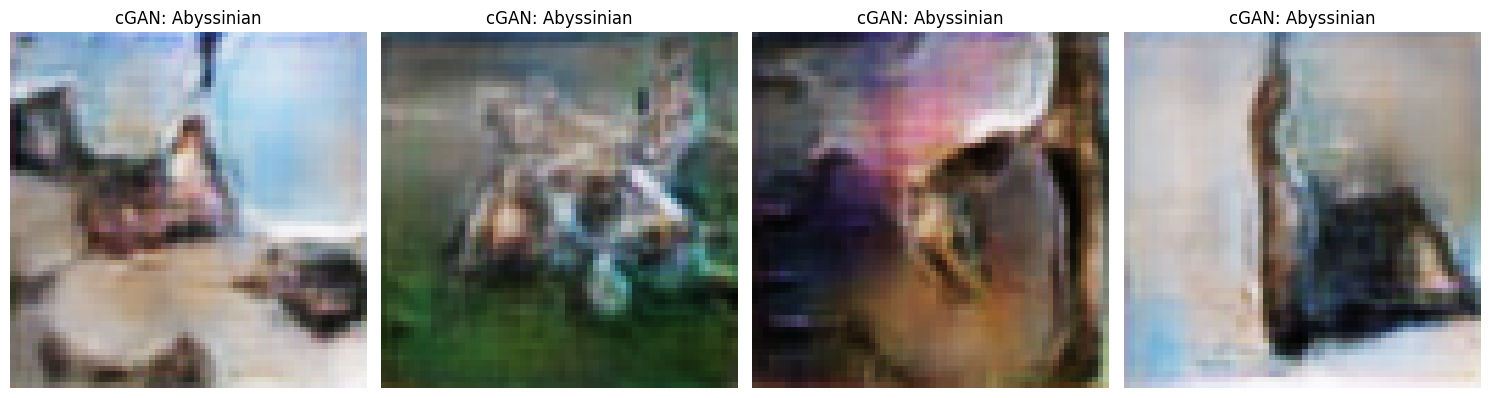

In [2]:
# ==============================================================================
# 🎨 Part 2.2: cGAN Inference / Image Generation Pipeline (Instant Sampling)
# 🎯 Goal: Load the 6M Generator and generate crisp pet images in a single pass
# ==============================================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Device Setup for Inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Inference Accelerator: {device.type.upper()}")

# 2. Load the ENTIRE Saved Generator Object safely
FINAL_GAN_PATH = "custom_6m_generator_pet_35epochs.pth"
LATENT_DIM = 100 # Must match the training dimension

if os.path.exists(FINAL_GAN_PATH):
    print(f"📦 Loading complete 6M Generator object from: {FINAL_GAN_PATH}")
    # Load entire object structure safely via CPU first, then push to active device
    generator = torch.load(FINAL_GAN_PATH, map_location="cpu", weights_only=False)
    generator = generator.to(device)
    generator.eval()
    print("✅ Generator pipeline successfully initialized in EVAL mode.")
else:
    print(f"❌ Error: Generator file not found at {FINAL_GAN_PATH}. Check your file execution context.")

# 3. cGAN Instant Sampling Function
@torch.no_grad()
def generate_gan_pet_images(generator_model, class_name, num_images=4):
    generator_model.eval()
    
    # Map input text prompt back to the class index
    if class_name not in dataset.class_to_idx:
        print(f"❌ Class '{class_name}' not found. Available samples: {list(dataset.class_to_idx.keys())[:3]}")
        return
        
    class_idx = dataset.class_to_idx[class_name]
    class_idxs = torch.tensor([class_idx] * num_images, dtype=torch.long).to(device)
    
    print(f"🎨 Generating {num_images} images via cGAN for prompt: '{class_name}'...")
    
    # ⚡ THE GAN ADVANTAGE: Just one single step forward pass, no 1000-step time loop!
    z = torch.randn(num_images, LATENT_DIM, device=device)
    generated_imgs = generator_model(z, class_idxs)
    
    # Post-processing: Denormalize images from [-1, 1] back to [0, 1] range
    generated_imgs = (generated_imgs.clamp(-1, 1) + 1.0) / 2.0
    generated_imgs = generated_imgs.cpu().permute(0, 2, 3, 1).numpy()
    
    # Plot the generated results
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[i].imshow(generated_imgs[i])
        title_display = class_name.split()[-2] if len(class_name.split()) >= 2 else class_name
        axes[i].set_title(f"cGAN: {title_display}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# 🚀 Run the cGAN Generation Test
if 'dataset' in locals() and len(dataset.unique_classes) > 0:
    sample_prompt = dataset.unique_classes[0] # Takes the first verified prompt (e.g., Abyssinian cat)
    generate_gan_pet_images(generator, class_name=sample_prompt, num_images=4)
else:
    print("⚠️ Dataset object not found in memory. Please ensure the dataset cells are active.")


In [3]:
# ==============================================================================
# 🔄 Part 2.3: Extending cGAN Training from Epoch 36 to 50 (15 More Epochs)
# ==============================================================================

# Ensure both models stay in training mode
generator.train()
discriminator.train()

START_EPOCH = 35
ADDITIONAL_EPOCHS = 15
TOTAL_TARGET_EPOCHS = START_EPOCH + ADDITIONAL_EPOCHS

print(f"🚀 Continuing cGAN training from Epoch {START_EPOCH + 1} up to Epoch {TOTAL_TARGET_EPOCHS}...")

for epoch in range(START_EPOCH, TOTAL_TARGET_EPOCHS):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{TOTAL_TARGET_EPOCHS}")
    
    for batch_idx, (real_imgs, labels) in progress_bar:
        batch_size = real_imgs.shape[0]
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        
        valid_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)
        
        # ---------------------------------
        # 🚂 Step A: Train Discriminator
        # ---------------------------------
        optimizer_D.zero_grad()
        
        real_logits = discriminator(real_imgs, labels)
        loss_real = adversarial_loss(real_logits, valid_targets)
        
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(z, labels)
        fake_logits = discriminator(fake_imgs.detach(), labels)
        loss_fake = adversarial_loss(fake_logits, fake_targets)
        
        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        
        if USE_TPU:
            xm.optimizer_step(optimizer_D, barrier=True)
        else:
            optimizer_D.step()
            
        epoch_d_loss += loss_D.item()
        
        # ---------------------------------
        # 🚂 Step B: Train Generator
        # ---------------------------------
        optimizer_G.zero_grad()
        
        gen_logits = discriminator(fake_imgs, labels)
        loss_G = adversarial_loss(gen_logits, valid_targets)
        loss_G.backward()
        
        if USE_TPU:
            xm.optimizer_step(optimizer_G, barrier=True)
        else:
            optimizer_G.step()
            
        epoch_g_loss += loss_G.item()
        
        progress_bar.set_postfix({"G_Loss": f"{loss_G.item():.4f}", "D_Loss": f"{loss_D.item():.4f}"})
        
    print(f"📢 Epoch {epoch+1} Summary | Final G_Loss: {epoch_g_loss/len(train_loader):.4f} | Final D_Loss: {epoch_d_loss/len(train_loader):.4f}\n")

print("🏆 Extended cGAN Training Completed Successfully!")

# 💾 Save the extended 50-epoch Generator Object
final_gan_50_name = "custom_6m_generator_pet_50epochs.pth"
torch.save(generator, final_gan_50_name)
print(f"✅ 50-epoch generator object saved successfully as: {final_gan_50_name}")


🚀 Continuing cGAN training from Epoch 36 up to Epoch 50...


Epoch 36/50:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 36 Summary | Final G_Loss: 4.1150 | Final D_Loss: 0.0528



Epoch 37/50:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 37 Summary | Final G_Loss: 5.5000 | Final D_Loss: 0.0103



...

📢 Epoch 48 Summary | Final G_Loss: 8.6476 | Final D_Loss: 0.0006



Epoch 49/50:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 49 Summary | Final G_Loss: 8.8222 | Final D_Loss: 0.0005



Epoch 50/50:   0%|          | 0/115 [00:00<?, ?it/s]

📢 Epoch 50 Summary | Final G_Loss: 8.8088 | Final D_Loss: 0.0005

🏆 Extended cGAN Training Completed Successfully!
✅ 50-epoch generator object saved successfully as: custom_6m_generator_pet_50epochs.pth
